In [1]:
# Modular PDE-Constrained Optimization with Neural Networks

#This notebook provides a unified interface to run all examples from the paper using the modular components.

## Running Options

### Option 1: Local GPU (WSL/Linux with NVIDIA GPU)

### Option 2: Google Colab GPU
#See instructions in cell below

In [2]:
# GPU Setup Check
import sys

# Detect environment
IN_COLAB = 'google.colab' in sys.modules

if IN_COLAB:
    print("Running in Google Colab")
    # Mount Google Drive for persistent storage
    from google.colab import drive
    drive.mount('/content/drive')
    
    # Install required packages
    !pip install -q jax[cuda12] -f https://storage.googleapis.com/jax-releases/jax_cuda_releases.html
    !pip install -q flax optax matplotlib
    !nvidia-smi
else:
    print("Running locally")
    # Optional: Check if running in virtual environment
    import os
    if hasattr(sys, 'real_prefix') or (hasattr(sys, 'base_prefix') and sys.base_prefix != sys.prefix):
        print(f"✓ Virtual environment active: {sys.prefix}")
    else:
        print("⚠ Not in virtual environment. Activate with: source venv/bin/activate")
    
# Check JAX and GPU
import jax
print(f"\nJAX version: {jax.__version__}")
print(f"Available devices: {jax.devices()}")
print(f"Backend: {jax.default_backend()}")

if jax.default_backend() == 'gpu':
    print("✓ GPU acceleration enabled!")
    # Try to get GPU info
    try:
        import subprocess
        result = subprocess.run(['nvidia-smi', '--query-gpu=name,memory.total', '--format=csv,noheader'], 
                              capture_output=True, text=True)
        if result.returncode == 0:
            print(f"GPU: {result.stdout.strip()}")
    except:
        pass
else:
    print("⚠ Running on CPU")

Running locally
✓ Virtual environment active: /Users/markmiller/pde-constrained-opt-nn/venv

JAX version: 0.4.13
Available devices: [CpuDevice(id=0)]
Backend: cpu
⚠ Running on CPU


## Setup and Imports

In [3]:
import jax
import jax.numpy as jnp
import flax.linen as nn
import optax
import matplotlib.pyplot as plt
import numpy as np
from functools import partial
from typing import Dict, Any, Tuple, Optional
import time

# Import modular components from pde_opt package
try:
    from pde_opt.solvers import get_solver
    from pde_opt.problems import get_problem
    from pde_opt.examples import get_example, create_neural_network
    from pde_opt.utils.plotting import plot_example_results, plot_loss_curves
    from pde_opt.utils.solver_validation import validate_solver, find_optimal_config
    print("✓ Modules loaded successfully")
except ImportError as e:
    print(f"⚠ Warning: Modules not found - {e}")
    print("Install the package with: pip install -e .")

# Set random seed for reproducibility
key = jax.random.PRNGKey(42)

# Configure matplotlib
plt.rcParams['figure.dpi'] = 100
plt.rcParams['font.size'] = 10

✓ Modules loaded successfully


## Module Definitions (if not imported)

If the modules aren't available, uncomment and run the cells below:

In [4]:
# Optional: Define create_neural_network function if modules not available
def create_neural_network(hidden_layers: list = [256, 256], activation: str = 'tanh'):
    """Create a neural network for force/parameter approximation."""
    
    class Network(nn.Module):
        layers: list
        activation: str
        
        @nn.compact
        def __call__(self, x):
            for i, features in enumerate(self.layers):
                x = nn.Dense(features)(x)
                if i < len(self.layers) - 1:
                    if self.activation == 'tanh':
                        x = nn.tanh(x)
                    elif self.activation == 'relu':
                        x = nn.relu(x)
            x = nn.Dense(1)(x)  # Output layer
            return x.squeeze(-1)
    
    return Network(layers=hidden_layers, activation=activation)

## Configuration: Select Problem and Solver

In [14]:
# Configuration - modify these to run different examples
CONFIG = {
    'example': '3.3',  # Options: '3.1', '3.2', '3.3', '3.5', '3.6'
    'max_iterations': 6000,
    # 'prob': 'cossinsin',  # For example 3.5: 'default' or 'cossinsin
    'problem_name': 'heat-1d-cosine',  # For example 3.3
    'discretization': 'fd',
    'nx': 200,
    'nt': 50,
    'T': 0.5,
    # 'n_oscillations': 20,  # For example 3.3
    # 'T': 0.5,
    
    'reg': 1e-8
}
    
print("Configuration:")
for key, value in CONFIG.items():
    print(f"  {key}: {value}")

Configuration:
  example: 3.3
  max_iterations: 6000
  problem_name: heat-1d-cosine
  discretization: fd
  nx: 200
  nt: 50
  T: 0.5
  reg: 1e-08


### Find Optimal Grid Configuration (Optional)

If solver validation failed above, run this cell to automatically find the optimal grid configuration that achieves <1% error (or the best achievable if <1% is unreachable with available memory).

In [16]:
# Validate solver accuracy before training
print("\n" + "="*60)
print("SOLVER VALIDATION")
print("="*60)

# Create example instance to validate
if CONFIG['example'] == '3.5':
    ex_validate = get_example(f"example-{CONFIG['example']}",
                              prob=CONFIG.get('prob', 'default'),
                              regularization=CONFIG.get('reg', None))
else:
    ex_validate = get_example(f"example-{CONFIG['example']}",
                              problem_name=CONFIG.get('problem_name', 'heat-1d'),
                              # n_oscillations=CONFIG.get('n_oscillations', 1),
                              regularization=CONFIG.get('reg', None))

# Validate with 1% threshold
is_valid, rel_error, details = validate_solver(ex_validate, threshold=0.01, verbose=True)

if not is_valid:
    print("\n" + "!"*60)
    print("⚠ WARNING: Solver error exceeds 1% threshold!")
    print("!"*60)
    print("\nOptions:")
    print("  1. Accept higher error (may impact accuracy of force recovery)")
    # print("  2. Find optimal grid configuration (run cell below)")
    # print("  3. Manually adjust grid_params in the example configuration")
    print("\nNote: For highly oscillatory problems, achieving <1% may require")
    print("      very fine grids that exceed GPU memory. In such cases, you may")
    print("      need to accept 5-15% solver error as a practical compromise.")
else:
    print("\n✓ Solver validation passed! Ready to train.")

print("="*60)


SOLVER VALIDATION

SOLVER VALIDATION
Problem: heat-1d-cosine (k=1)
Grid: nx=149, nt=50

Results:
  MSE:              2.153885e-05
  Relative L2:      9.251001e-03 (0.93%)
  Threshold:        1.000000e-02 (1.00%)

Status: ✓ PASS - Solver accuracy is sufficient


✓ Solver validation passed! Ready to train.


In [7]:
# Uncomment and run this cell if validation failed above
# This will search for optimal grid parameters to achieve <1% error

# print("\n" + "="*60)
# print("FINDING OPTIMAL CONFIGURATION")
# print("="*60)

# optimal_config = find_optimal_config(ex_validate, threshold=0.01, max_nx=200)

# if optimal_config['achievable']:
#     print(f"\n✓ Found optimal configuration achieving {optimal_config['best_error']*100:.2f}% error:")
#     print(f"  Recommended grid_params: {optimal_config['best_config']}")
#     print("\nUpdate your example configuration with these parameters.")
# else:
#     print(f"\n⚠ Could not achieve <1% error within max_nx={200}")
#     print(f"  Best achievable: {optimal_config['best_error']*100:.2f}% error")
#     print(f"  Best config: {optimal_config['best_config']}")
#     print("\nYou may need to accept higher solver error or use a GPU with more memory.")

# print("="*60)

## Validate Solver Accuracy (Optional but Recommended)

Before training, it's highly recommended to validate that the forward solver has acceptable accuracy with the current grid configuration. The solver should have <1% error with ground truth forcing to accurately recover the forcing term via neural network training.

Run this cell to check if your solver configuration is adequate. If not, it will suggest optimal grid parameters.

## Initialize Problem and Solver

In [17]:
# Run the selected example
print(f"\nRunning Example {CONFIG['example']}...")
print("="*60)


# Get and run example
if CONFIG['example'] == '3.5':
    # For 3.5, pass the 'prob' parameter
    ex = get_example(f"example-{CONFIG['example']}",
                     prob=CONFIG.get('prob', 'default'),
                     regularization=CONFIG.get('reg', None))
else:
    ex = get_example(f"example-{CONFIG['example']}",
                     problem_name=CONFIG.get('problem_name', 'heat-1d'),
                     # n_oscillations=CONFIG.get('n_oscillations', 1),
                     T=CONFIG.get('T', 1.0),
                     regularization=CONFIG.get('reg', None))

# Run based on example type
if CONFIG['example'] == '3.1':
    # Scalar force estimation
    force_scalar, losses, solution = ex.run(max_iter=CONFIG['max_iterations'])
    print(f"\nFinal force estimate: {force_scalar:.6f} (true: -1.0)")
    # Store for plotting
    force = force_scalar
    params = None
    
elif CONFIG['example'] == '3.2':
    # Vector force estimation
    force_vector, losses, solution = ex.run(max_iter=CONFIG['max_iterations'])
    print(f"\nFinal loss: {losses[-1]:.6e}")
    # Store for plotting
    force = force_vector
    params = None
    
elif CONFIG['example'] in ['3.3', '3.5', '3.6']:
    # Neural network force estimation
    params, losses, force, solution = ex.run(max_iter=CONFIG['max_iterations'])
    print(f"\nFinal loss: {losses[-1]:.6e}")
    
    # Print NN info
    n_params = sum(x.size for x in jax.tree_util.tree_leaves(params))
    print(f"NN parameters: {n_params}")

print("="*60)


Running Example 3.3...
Using TIME-STEPPING solver (matches working notebook)
ep    0 | L=0.214611 | mis=0.214611 | regF=0.000000
ep   50 | L=0.188055 | mis=0.188055 | regF=0.000000
ep  100 | L=0.004576 | mis=0.004571 | regF=0.000005
ep  150 | L=0.002339 | mis=0.002334 | regF=0.000005
ep  200 | L=0.002149 | mis=0.002145 | regF=0.000005
ep  250 | L=0.002387 | mis=0.002382 | regF=0.000005
ep  300 | L=0.001884 | mis=0.001879 | regF=0.000005
ep  350 | L=0.001780 | mis=0.001775 | regF=0.000005
ep  400 | L=0.001687 | mis=0.001682 | regF=0.000005
ep  450 | L=0.003585 | mis=0.003580 | regF=0.000005
ep  500 | L=0.001551 | mis=0.001546 | regF=0.000005
ep  550 | L=0.001454 | mis=0.001449 | regF=0.000005
ep  600 | L=0.002096 | mis=0.002092 | regF=0.000005
ep  650 | L=0.001344 | mis=0.001339 | regF=0.000005
ep  700 | L=0.001264 | mis=0.001259 | regF=0.000005
ep  750 | L=0.001206 | mis=0.001201 | regF=0.000005
ep  800 | L=0.002316 | mis=0.002312 | regF=0.000005
ep  850 | L=0.001113 | mis=0.001109 | 

## Visualization and Results

The plotting module automatically detects the problem type and generates appropriate visualizations:
- **Loss curves**: Training progress (linear and log scale)
- **1D problems**: Line plots comparing true vs predicted solutions
- **1+1D problems**: Space-time heatmaps and temporal snapshots
- **2+1D problems**: 2D spatial snapshots at different time steps
- **Error analysis**: Difference maps and quantitative metrics


Generating plots...


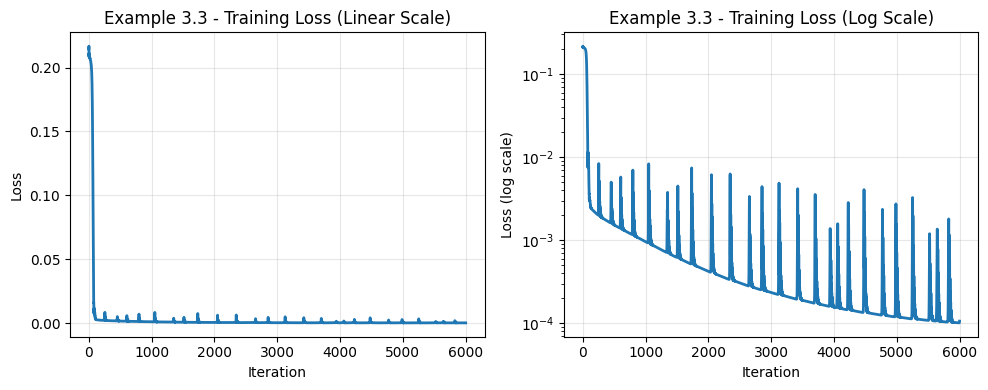

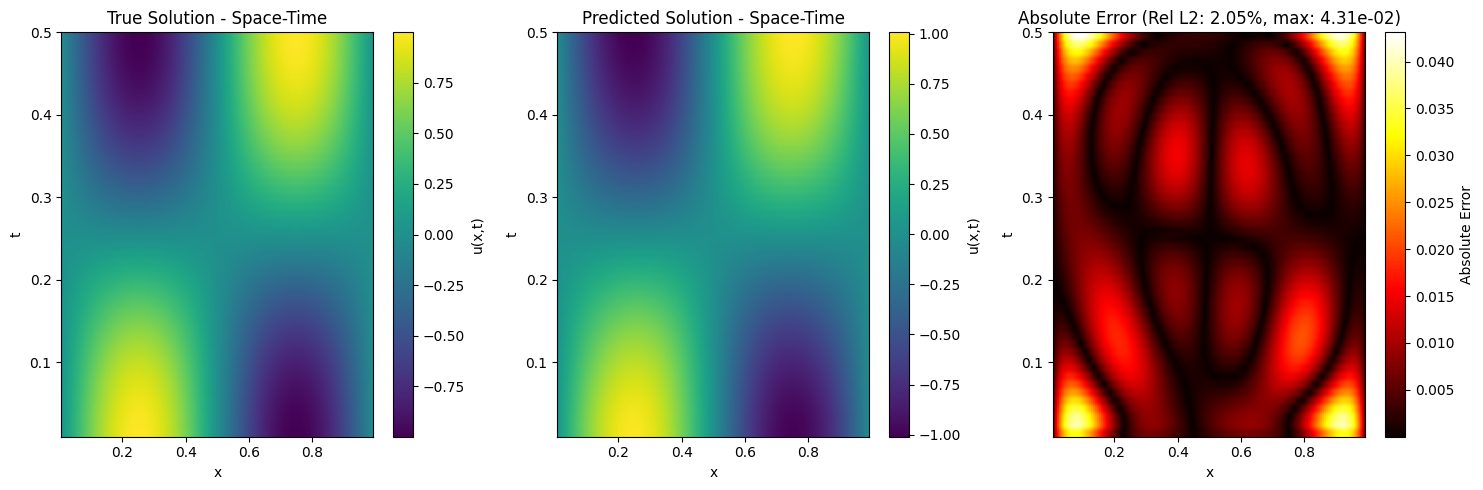

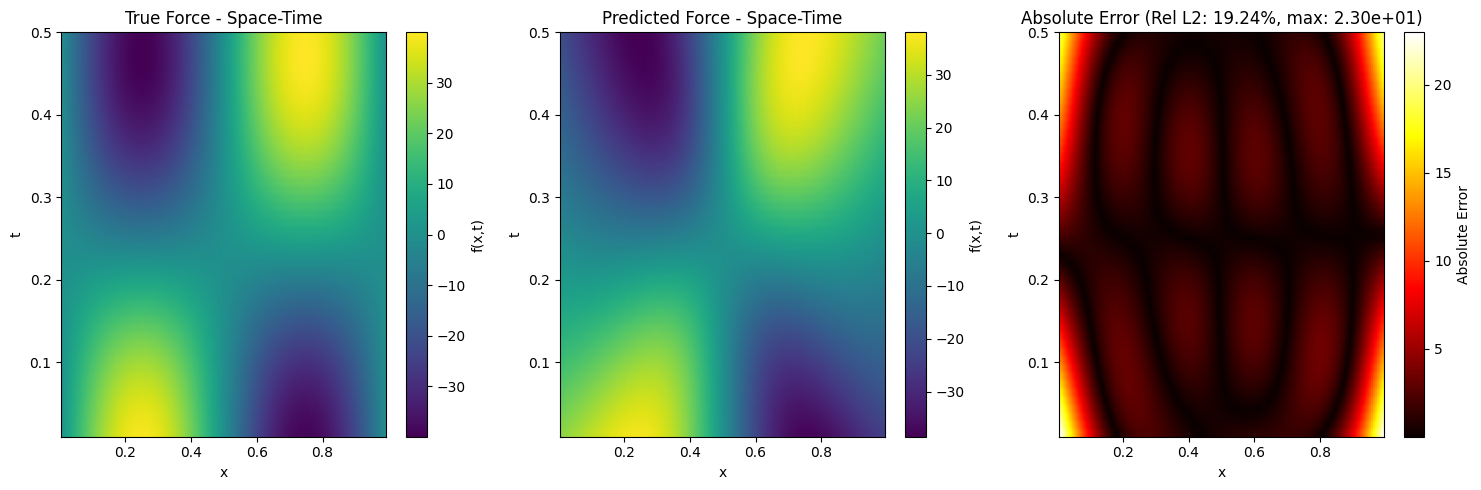

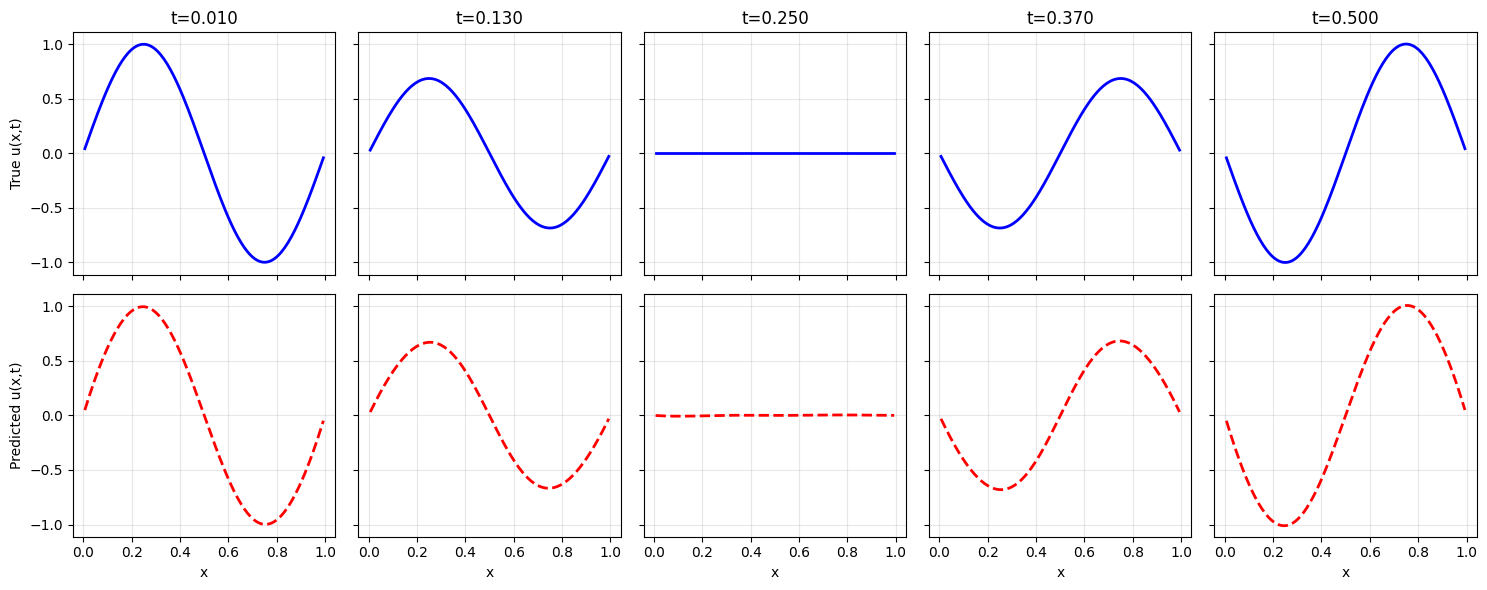

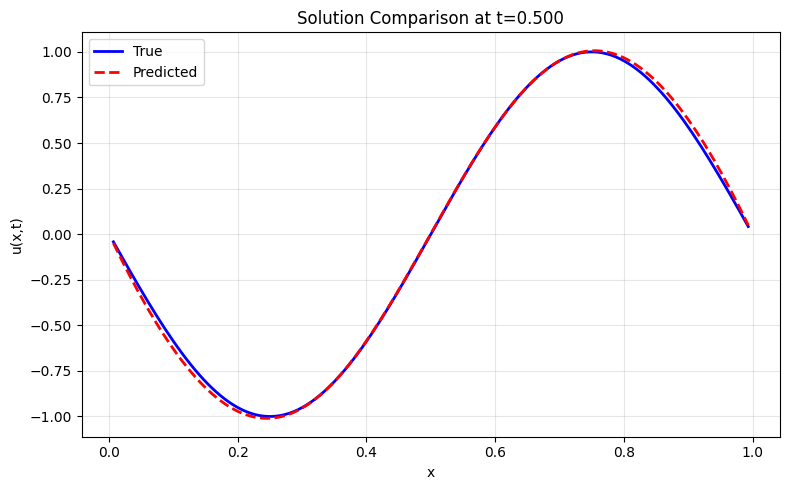


📊 Error Metrics:
  MSE:              1.058730e-04
  Relative L2:      2.051021e-02 (2.05%)
  Final loss:       1.061318e-04
  Initial loss:     2.146114e-01
  Loss reduction:   99.95%


In [18]:
# Unified plotting for all examples
print("\nGenerating plots...")
print("="*60)

# Get solver and problem for plotting
T = ex.problem_kwargs.get('T', 1.0) if hasattr(ex, 'problem_kwargs') else 1.0
solver = get_solver(ex.solver_type, ex.discretization, T=T, **ex.grid_params)

# Pass appropriate parameters based on example type
if CONFIG['example'] == '3.5':
    # For 3.5, pass the 'prob' parameter
    problem = get_problem(ex.problem_name, prob=CONFIG.get('prob', 'default'))
elif hasattr(ex, 'problem_kwargs'):
    # For examples with problem_kwargs (like 3.3 with n_oscillations)
    problem = get_problem(ex.problem_name, **ex.problem_kwargs)
else:
    problem = get_problem(ex.problem_name)

# Plot results automatically based on example type
figures = plot_example_results(
    example_name=f"Example {CONFIG['example']}",
    solver=solver,
    problem=problem,
    params=params,
    losses=losses,
    force=force,
    solution=solution,
    max_snapshots=5,
    figsize_scale=1.0
)

plt.show()

# Print error metrics if applicable
if solution is not None and hasattr(solver, 't_grid'):
    # Time-dependent problem
    x_grid = solver.x_grid
    t_grid = solver.t_grid
    
    if hasattr(solver, 'y_grid'):
        # 2D spatial
        y_grid = solver.y_grid
        nx, ny, nt = solver.nx, solver.ny, solver.nt
        u_pred = solution.reshape(nx, ny, nt)
        u_true = jnp.stack([problem.analytical_solution(x_grid, y_grid, t) for t in t_grid], axis=-1)
    else:
        # 1D spatial
        nx, nt = solver.nx, solver.nt
        u_pred = solution.reshape(nx, nt)
        u_true = problem.analytical_solution(x_grid, t_grid)
    
    mse = jnp.mean((u_pred - u_true)**2)
    rel_err = jnp.linalg.norm(u_pred.flatten() - u_true.flatten()) / jnp.linalg.norm(u_true.flatten())
    
    print(f"\n📊 Error Metrics:")
    print(f"  MSE:              {mse:.6e}")
    print(f"  Relative L2:      {rel_err:.6e} ({100*rel_err:.2f}%)")
    print(f"  Final loss:       {losses[-1]:.6e}")
    print(f"  Initial loss:     {losses[0]:.6e}")
    print(f"  Loss reduction:   {100*(1 - losses[-1]/losses[0]):.2f}%")

print("="*60)

Saved: results/figures/loss.png
Saved: results/figures/solution_spacetime.png
Saved: results/figures/force_spacetime.png
Saved: results/figures/solution_snapshots.png
Saved: results/figures/final_comparison.png


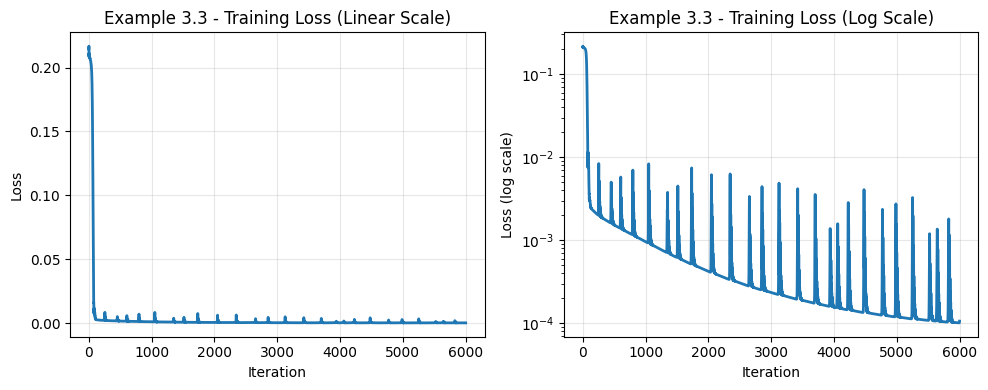

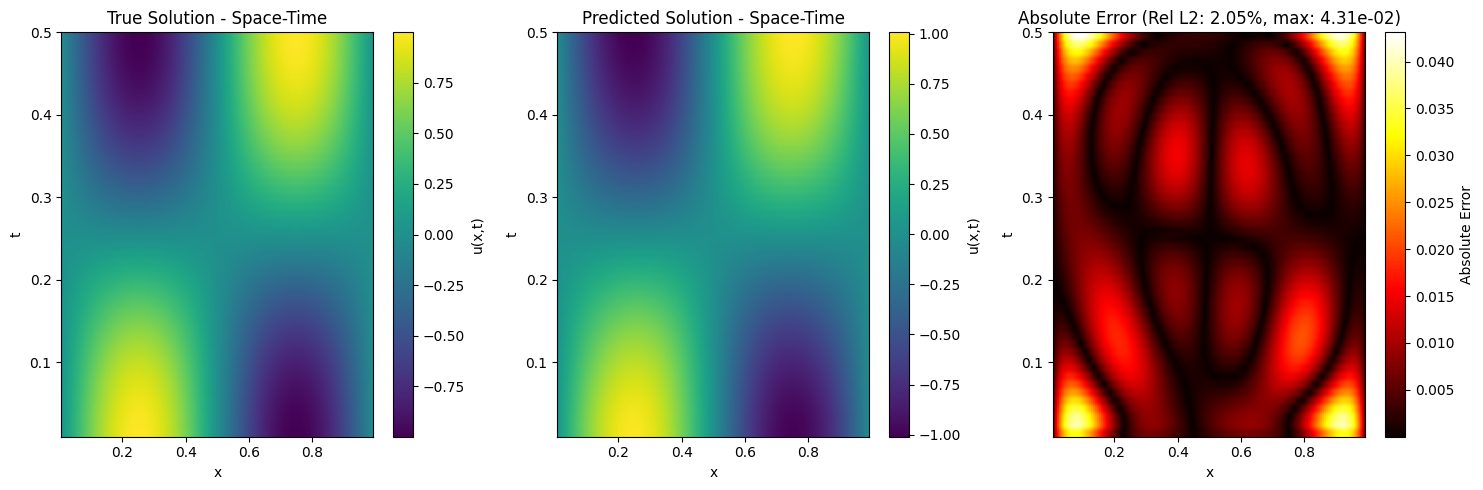

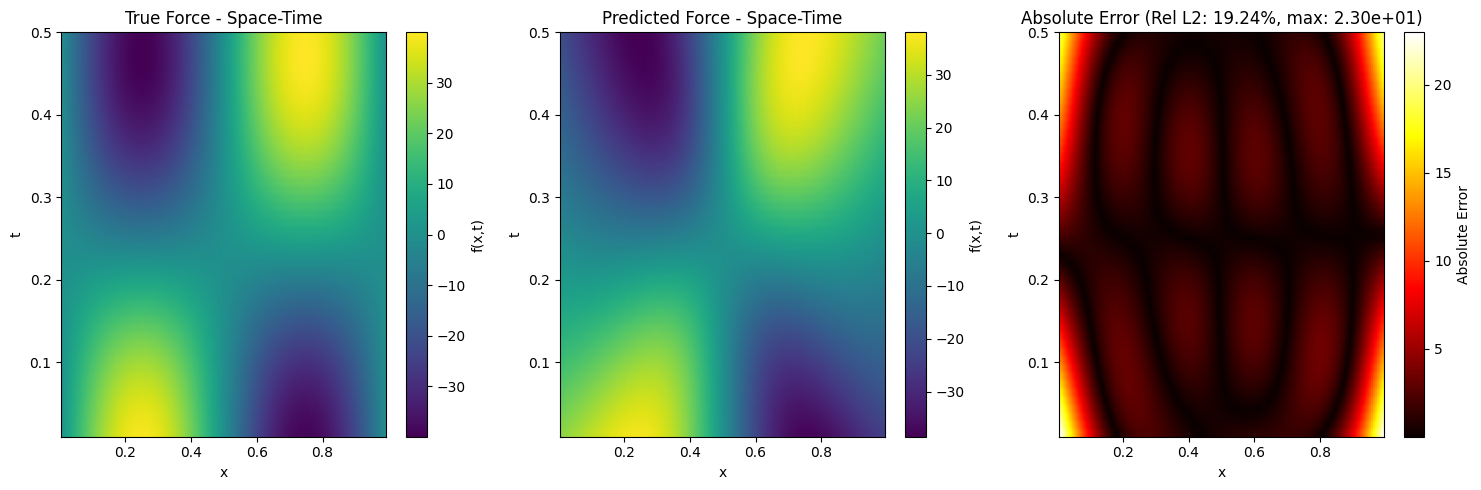

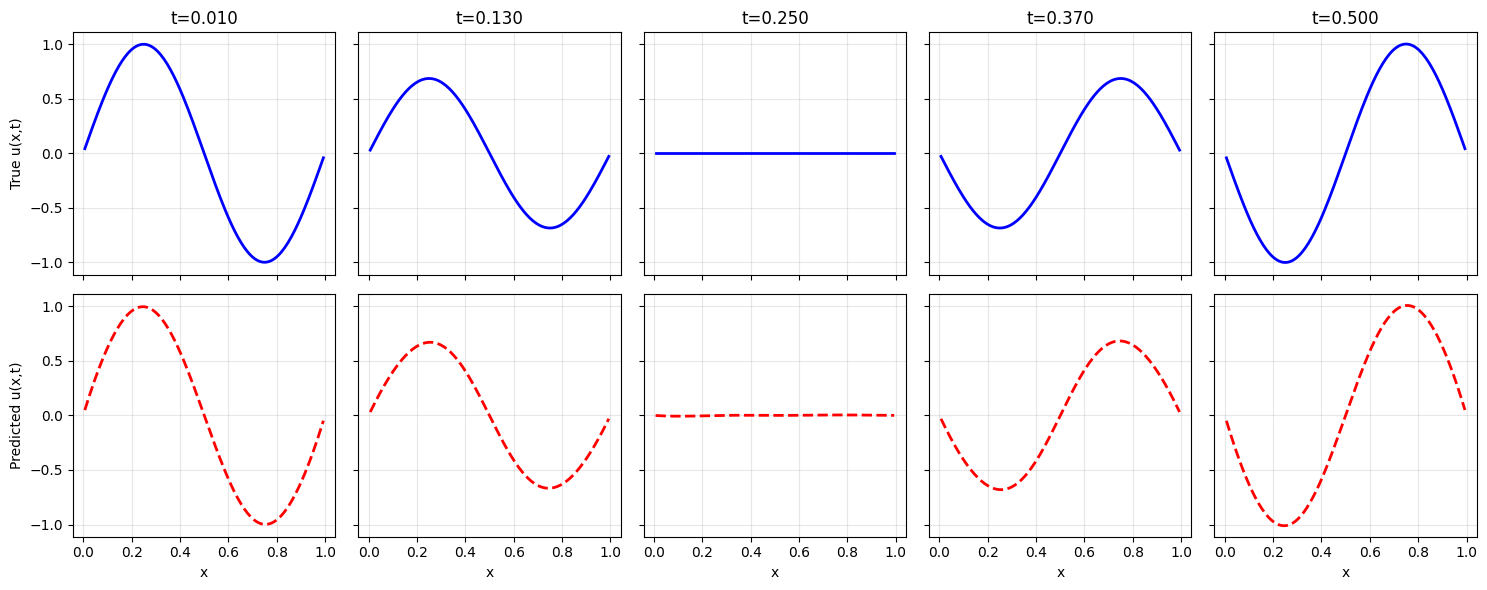

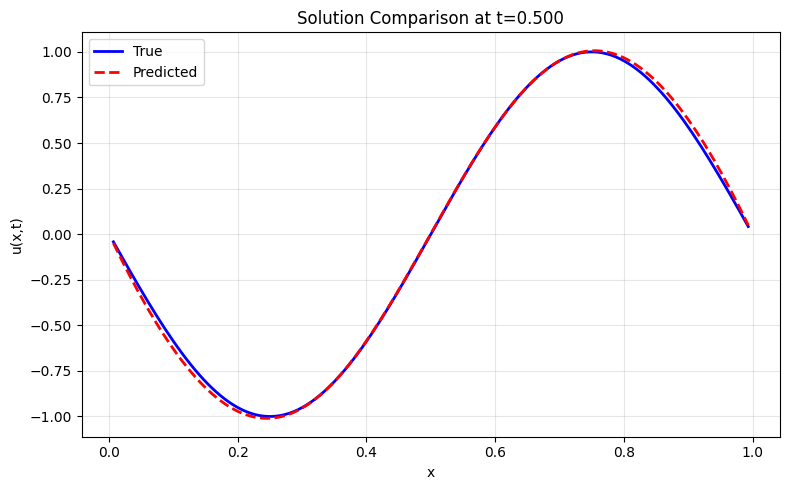

In [20]:
figures = plot_example_results(
      example_name=f"Example {CONFIG['example']}",
      solver=solver,
      problem=problem,
      params=params,
      losses=losses,
      force=force,
      solution=solution,
      max_snapshots=5,
      figsize_scale=1.0
)

# Save all figures
import os
from pathlib import Path

# Create output directory
output_dir = Path('results/figures')
output_dir.mkdir(parents=True, exist_ok=True)

# Save each figure
for fig_name, fig in figures.items():
    filepath = output_dir / f"{fig_name}.png"
    fig.savefig(filepath, dpi=300, bbox_inches='tight')
    print(f"Saved: {filepath}")

# # Or save as PDF for publication quality
# for fig_name, fig in figures.items():
#     filepath = output_dir / f"{fig_name}.pdf"
#     fig.savefig(filepath, bbox_inches='tight')
#     print(f"Saved: {filepath}")

#   #You can also be more specific with the filename based on your
#   #problem:

#   # Create a descriptive prefix
#   problem_name = CONFIG.get('problem_name', 'heat-1d')
#   timestamp = time.strftime('%Y%m%d_%H%M%S')
#   prefix = f"{problem_name}_{timestamp}"

#   # Save with descriptive names
#   for fig_name, fig in figures.items():
#       filepath = output_dir / f"{prefix}_{fig_name}.png"
#       fig.savefig(filepath, dpi=300, bbox_inches='tight')
#       print(f"Saved: {filepath}")